# **Business Case 1: Segmenting Clients**
<br>

## Goal

Here we have a random extraction of **a (real-world) dataset made up of a bank's customers**. The data is **anonymous, mostly clean and normalized in [0, 1]**.

We intend to **segment these customers using Data Science techniques** (essentially Unsupervised Machine Learning); this is a segmentation carried out from the perspective of the financial services sector.


The **dataset is called "Dataset1_BankClients"** and is saved as a .xls file.

<br>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import adjusted_mutual_info_score

import Utilities



In [2]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)
# Don't drop the id
#data = data.drop(columns=['ID'])
data.head()


,ID,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,1,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,2,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,3,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,4,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,5,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Preparing data

### Data cleaning

Since the data is a  mix of **Numerical** and **Categorical** we need to find a proper measure to make them standard.


We have to:
* **Encode categorical variables**, so that they can be digestible by clustering algorithms - they are all trasformed in boolean variables by one-hot encoding.
* **Normalize** in [0, 1] numerical variables.

### Business Lens Analysis

Features are grouped into three business lenses capturing different aspects of the client's financial profile.

**Lens 1: Financial Capacity & Stress ("The Wallet")**
Focuses on hard financial indicators — what the client earns, owns, and owes.
Features: Income (annual earnings), Wealth (total assets), Debt (total liabilities).

**Lens 2: Bank Engagement & Literacy ("The Relationship")**
Captures how the client interacts with the financial system and the bank.
Features: FinEdu (financial education), Digital (digital adoption), BankFriend (relationship strength).

**Lens 3: Spending & Behavioral Persona ("The Choices")**
Reflects how the client allocates and uses their money.
Features: Lifestyle, Luxury, Saving, Investments, ESG.

#### Behavioral Clustering and Demographic Profiling

Clustering is performed exclusively on the **behavioral dimensions represented by the three lenses**, allowing the model to identify groups of clients who share similar financial habits and decision patterns.

**Demographic variables (e.g., Age, Gender, Job, Area, CitySize)** are not included in the clustering process. Incorporating them directly would risk forming clusters driven by location or occupation rather than genuine financial behavior.

Instead, demographics are used **after clustering** to profile and interpret the discovered personas.
For example, once a behavioral segment such as *“Aggressive Digital Investors”* emerges, demographic variables help answer questions like **where these clients tend to live, what jobs they hold, or what age groups they belong to**.

This separation ensures that clusters reflect **true behavioral patterns**, while demographics provide **context for business interpretation and strategy**.

### Distance measure

<br>

**First of all we need a proper distance** there are many distances - [Comprehensive Survey on Distance/Similarity Measures between Probability Density Functions](http://www.fisica.edu.uy/~cris/teaching/Cha_pdf_distances_2007.pdf): a suitable one is the **Gower's distance**, because it is specifically designed for mixed categorical and numerical data.

The Gower distance is the **average of all individual feature distances**. Nothing special: it ensures that each feature contributes proportionally, preventing any one type from dominating.

<br>



In [3]:
# DATA CLEANING & OUTLIER REMOVAL
CATEGORICAL_COLS = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
CONTINUOUS_COLS  = [col for col in data.columns if col not in CATEGORICAL_COLS]

data = Utilities.find_outliers_selective(data, CONTINUOUS_COLS)

Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.


In [4]:
# DEFINE LENSES & DEMOGRAPHICS

LENS_COLS = {
    'lens1': ['Income', 'Wealth', 'Debt'],
    'lens2': ['FinEdu', 'Digital', 'BankFriend'],
    'lens3': ['LifeStyle', 'Luxury', 'Investments', 'Saving', 'ESG'],
}
DEMO_COLS = ['ID', 'Age', 'Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

LENS3_ORDINAL_COLS = ['Investments']
LENS3_CONT_COLS    = [c for c in LENS_COLS['lens3'] if c not in LENS3_ORDINAL_COLS]

# SPLIT & CAST
df_lens1 = data[LENS_COLS['lens1']].copy()
df_lens2 = data[LENS_COLS['lens2']].copy()
df_lens3 = data[LENS_COLS['lens3']].copy()
df_demo  = data[DEMO_COLS].copy()

# Keep Investments as int — ordinal distance respects 1 < 2 < 3
df_lens3[LENS3_ORDINAL_COLS] = df_lens3[LENS3_ORDINAL_COLS].astype(int)

In [5]:
# NORMALIZE — each lens gets its own scaler

df_lens1_norm = Utilities.normalize_df(df_lens1, MinMaxScaler())
df_lens2_norm = Utilities.normalize_df(df_lens2, MinMaxScaler())
df_lens3_norm = Utilities.normalize_df(df_lens3, MinMaxScaler())

# COMPUTE DISTANCE MATRICES

best_k1, weights1, score1, dist_mat_lens1 = Utilities.build_lens_distance(
    df_lens1_norm, cont_cols=LENS_COLS['lens1']
)
best_k2, weights2, score2, dist_mat_lens2 = Utilities.build_lens_distance(
    df_lens2_norm, cont_cols=LENS_COLS['lens2']
)
best_k3, weights3, score3, dist_mat_lens3 = Utilities.build_lens_distance(
    df_lens3_norm, cont_cols=LENS3_CONT_COLS, ordinal_cols=LENS3_ORDINAL_COLS
)

print("Data preprocessing complete. Distance matrices ready for clustering.")

Data preprocessing complete. Distance matrices ready for clustering.


In [6]:
# summary of lenses
Utilities.print_lens_summary("lens1", LENS_COLS['lens1'], best_k1, score1)

Utilities.print_lens_summary("lens2", LENS_COLS['lens2'], best_k2, score2)

Utilities.print_lens_summary("lens3", LENS_COLS['lens3'], best_k3, score3, weights3)

LENS1 — Income / Wealth / Debt
  Clusters   : 2
  Silhouette : 0.3384
LENS2 — FinEdu / Digital / BankFriend
  Clusters   : 2
  Silhouette : 0.3494
LENS3 — LifeStyle / Luxury / Investments / Saving / ESG
  Clusters   : 3
  Silhouette : 0.7835
  Continuous alpha : 0.233
  Ordinal beta     : 0.500


In [7]:
#  CLUSTER EACH LENS INDEPENDENTLY (Using Agglomerative)
print("Running Agglomerative clustering on distance matrices...")

agg_lens1 = AgglomerativeClustering(n_clusters=best_k1, metric='precomputed', linkage='average')
agg_lens2 = AgglomerativeClustering(n_clusters=best_k2, metric='precomputed', linkage='average')
agg_lens3 = AgglomerativeClustering(n_clusters=best_k3, metric='precomputed', linkage='average')

# Fit the models and extract the cluster labels (0, 1, or 2)
labels_lens1 = agg_lens1.fit_predict(dist_mat_lens1)
labels_lens2 = agg_lens2.fit_predict(dist_mat_lens2)
labels_lens3 = agg_lens3.fit_predict(dist_mat_lens3)

print("Clustering successful!")


Running Agglomerative clustering on distance matrices...
Clustering successful!


In [8]:
# build a summary table
df_final, persona_counts, summary_table = Utilities.build_personas(df_demo, data, labels_lens1, labels_lens2, labels_lens3)


--- TOP DOMINANT PERSONAS ---
   Lens1_Capacity  Lens2_Engagement  Lens3_Behavior  Client_Count  Percentage  \
0               1                 0               1          1491   29.861807   
1               1                 0               0           841   16.843581   
2               1                 0               2           679   13.599039   
3               1                 1               1           472    9.453235   
4               0                 0               2           462    9.252954   

   Persona_ID  
0           1  
1           2  
2           3  
3           4  
4           5  

--- PERSONA PILLAR SUMMARY ---


,Client_Count,DebtCycleStress,FinancialLiteracy,ManagementApproach
Persona_ID,,,,
1,1491,0.541,0.549,0.800
2,841,0.530,0.544,0.320
3,679,0.514,0.539,0.558
4,472,0.455,0.604,0.764
5,462,0.427,0.528,0.562
6,352,0.436,0.601,0.516
7,342,0.430,0.520,0.314
8,219,0.436,0.529,0.792
9,124,0.477,0.611,0.286


In [9]:
# t-sne plotting

# Utilities.plot_lens_tsne(dist_mat_lens1, dist_mat_lens2, dist_mat_lens3,
#                          labels_lens1, labels_lens2, labels_lens3)
#
# Utilities.plot_global_tsne(dist_mat_lens1, dist_mat_lens2, dist_mat_lens3, df_final, persona_counts)

In [10]:
summary = Utilities.persona_statistics(df_final)
summary.to_excel('persona_summary.xlsx')

display(summary)

,Client_Count,Age_mean,Age_median,Age_std,FamilySize_mean,FamilySize_median,FamilySize_std,DebtCycleStress_mean,DebtCycleStress_median,DebtCycleStress_std,FinancialLiteracy_mean,FinancialLiteracy_median,FinancialLiteracy_std,ManagementApproach_mean,ManagementApproach_median,ManagementApproach_std,Gender,Job,Area,CitySize
Persona_ID,,,,,,,,,,,,,,,,,,,,
1,1491,57.808,57.0,22.410,2.715,3.0,1.527,0.541,0.542,0.152,0.549,0.539,0.134,0.800,0.800,0.068,1 (55%),2 (79%),1 (72%),2 (43%)
2,841,57.804,57.0,23.315,2.761,3.0,1.506,0.530,0.541,0.152,0.544,0.535,0.132,0.320,0.325,0.076,1 (55%),2 (77%),1 (68%),2 (44%)
3,679,59.798,59.0,21.649,2.521,2.0,1.439,0.514,0.526,0.161,0.539,0.528,0.139,0.558,0.561,0.068,1 (57%),2 (74%),1 (74%),2 (42%)
4,472,52.669,54.0,14.497,2.186,2.0,1.199,0.455,0.452,0.134,0.604,0.600,0.162,0.764,0.761,0.063,0 (58%),2 (83%),1 (83%),3 (62%)
5,462,77.584,80.0,14.812,2.132,2.0,1.105,0.427,0.426,0.097,0.528,0.514,0.142,0.562,0.562,0.053,1 (61%),5 (68%),1 (66%),2 (46%)
6,352,50.920,52.0,12.637,2.074,2.0,1.107,0.436,0.445,0.117,0.601,0.568,0.159,0.516,0.518,0.056,0 (61%),2 (82%),1 (81%),3 (68%)
7,342,75.368,80.0,19.181,2.208,2.0,1.194,0.430,0.435,0.106,0.520,0.508,0.145,0.314,0.319,0.066,1 (52%),5 (60%),1 (66%),2 (48%)
8,219,70.758,75.0,20.084,2.402,2.0,1.318,0.436,0.423,0.118,0.529,0.508,0.143,0.792,0.794,0.059,1 (54%),5 (42%),1 (72%),2 (51%)
9,124,49.589,50.0,19.107,2.323,2.0,1.341,0.477,0.476,0.152,0.611,0.585,0.157,0.286,0.296,0.085,0 (55%),2 (72%),1 (83%),3 (50%)


### Create a PERSONA TABLE (DEMOGRAPHIC PROFILING)

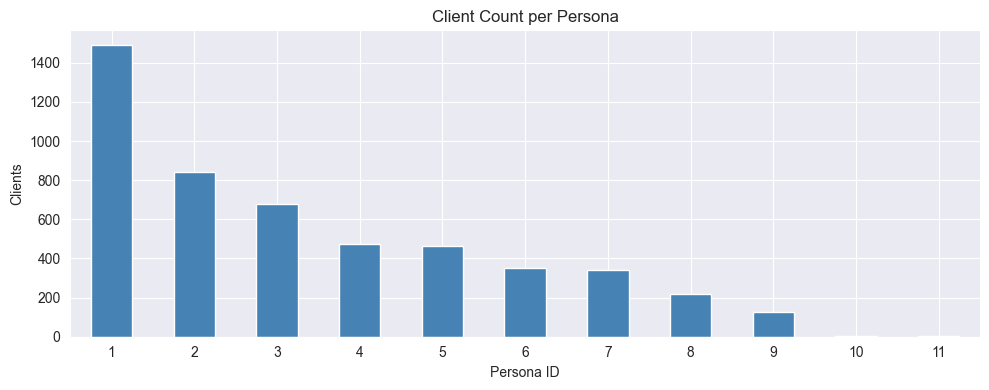

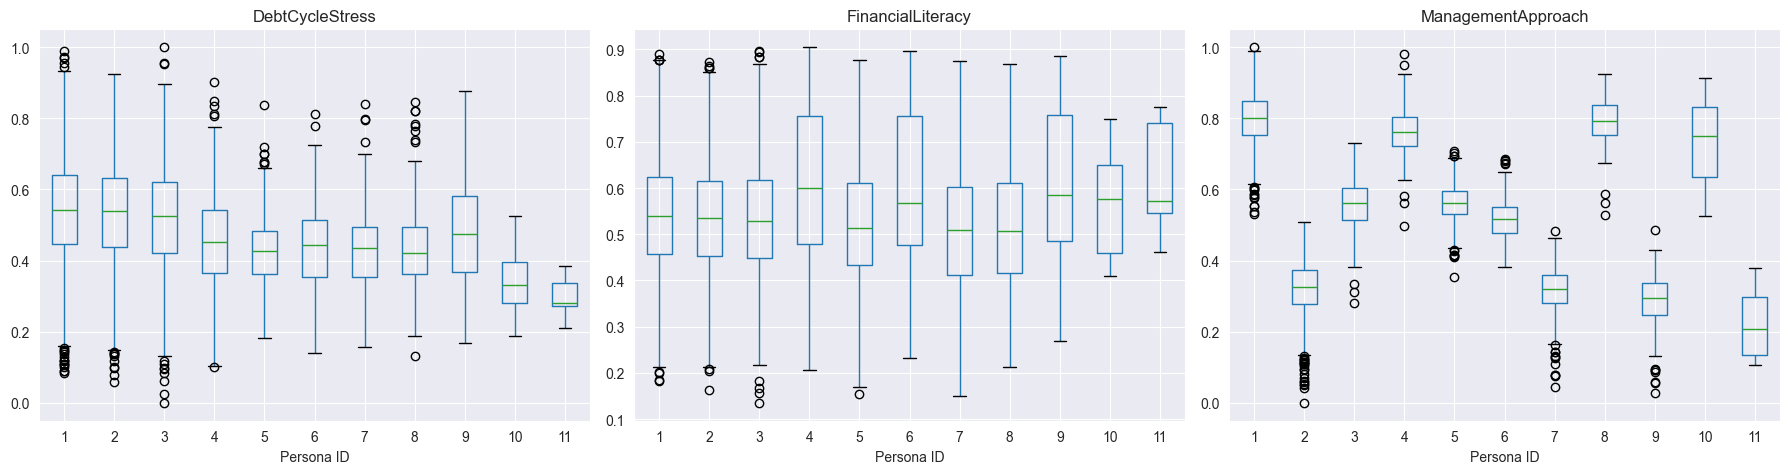

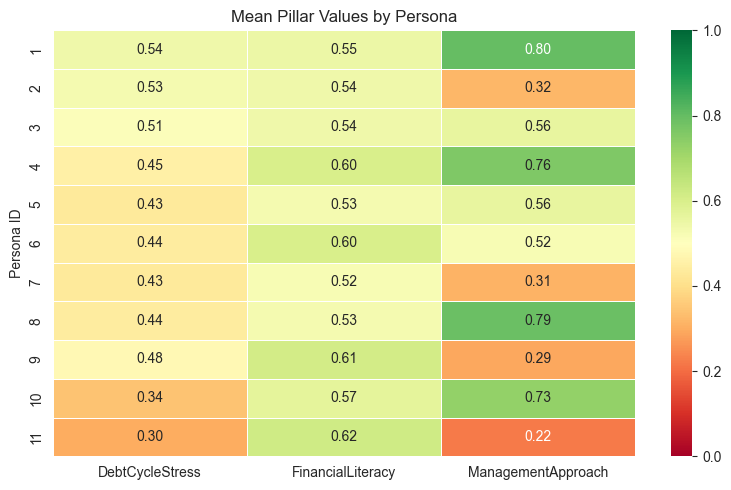

In [11]:
import plotly.graph_objects as go

def plot_persona_radar(df, top_n=8):
    """Radar chart: behavioral fingerprint of top N personas by size."""
    pillars = ['DebtCycleStress', 'FinancialLiteracy', 'ManagementApproach']

    means = (df.groupby('Persona_ID')[pillars].mean()
               .join(df.groupby('Persona_ID').size().rename('n'))
               .nlargest(top_n, 'n'))

    fig = go.Figure()
    for persona_id, row in means.iterrows():
        values = row[pillars].tolist()
        values.append(values[0])  # close the loop
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=pillars + [pillars[0]],
            fill='toself',
            name=f"Persona {persona_id} (n={int(row['n'])})"
        ))

    fig.update_layout(
        title=f"Behavioral Fingerprint — Top {top_n} Personas",
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        template='plotly_white'
    )
    fig.show()


def plot_persona_size(df):
    """Bar chart: how many clients per persona."""
    counts = df['Persona_ID'].value_counts().sort_index()
    plt.figure(figsize=(10, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Client Count per Persona')
    plt.xlabel('Persona ID')
    plt.ylabel('Clients')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_pillar_boxplots(df):
    """Boxplots: within-persona variance for each pillar."""
    pillars = ['DebtCycleStress', 'FinancialLiteracy', 'ManagementApproach']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, pillar in zip(axes, pillars):
        df.boxplot(column=pillar, by='Persona_ID', ax=ax)
        ax.set_title(pillar)
        ax.set_xlabel('Persona ID')
        plt.suptitle('')
    plt.tight_layout()
    plt.show()


def plot_pillar_heatmap(df):
    """Heatmap: mean pillar values per persona — good for presentations."""
    pillars = ['DebtCycleStress', 'FinancialLiteracy', 'ManagementApproach']
    means = df.groupby('Persona_ID')[pillars].mean().round(2)
    means = means.join(df.groupby('Persona_ID').size().rename('n'))
    means = means.sort_values('n', ascending=False).drop(columns='n')

    plt.figure(figsize=(8, 5))
    sns.heatmap(means, annot=True, cmap='RdYlGn', vmin=0, vmax=1,
                linewidths=0.5, fmt='.2f')
    plt.title('Mean Pillar Values by Persona')
    plt.ylabel('Persona ID')
    plt.tight_layout()
    plt.show()

plot_persona_radar(df_final, top_n=8)
plot_persona_size(df_final)
plot_pillar_boxplots(df_final)
plot_pillar_heatmap(df_final)

In [12]:
def persona_distinctive_features(df, top_n_features=3):
    """
    For each persona, computes z-scores of feature means relative to
    the global population. Returns a summary of the most distinctive
    features (highest absolute z-score) per persona.
    """
    features = ['Age', 'FamilySize', 'DebtCycleStress', 'FinancialLiteracy', 'ManagementApproach']

    global_mean = df[features].mean()
    global_std  = df[features].std()

    persona_means = df.groupby('Persona_ID')[features].mean()
    z_scores = (persona_means - global_mean) / global_std

    # For each persona, pick the top N most distinctive features
    records = []
    for persona_id, row in z_scores.iterrows():
        top_features = row.abs().nlargest(top_n_features).index.tolist()
        for feat in top_features:
            records.append({
                'Persona_ID': persona_id,
                'Feature':    feat,
                'Z_Score':    round(row[feat], 2),
                'Direction':  'above avg' if row[feat] > 0 else 'below avg',
            })

    return pd.DataFrame(records), z_scores


distinctive_df, z_scores = persona_distinctive_features(df_final, top_n_features=3)
display(distinctive_df)

,Persona_ID,Feature,Z_Score,Direction
0,1,ManagementApproach,1.00,above avg
1,1,DebtCycleStress,0.31,above avg
2,1,FamilySize,0.16,above avg
3,2,ManagementApproach,-1.32,below avg
4,2,DebtCycleStress,0.24,above avg
5,2,FamilySize,0.19,above avg
6,3,ManagementApproach,-0.17,below avg
7,3,DebtCycleStress,0.13,above avg
8,3,FinancialLiteracy,-0.09,below avg
9,4,ManagementApproach,0.82,above avg


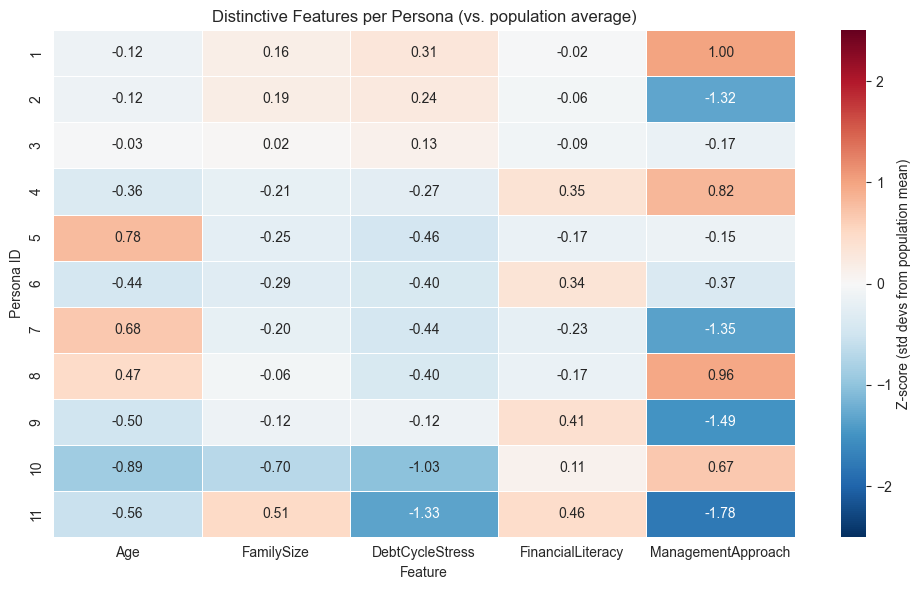

In [13]:
def plot_distinctive_heatmap(z_scores):
    """
    Diverging heatmap of z-scores: red = above average, blue = below average.
    Each cell shows how many std devs that persona deviates from the population.
    """
    # Sort personas by size if you have counts, otherwise just by ID
    counts = df_final['Persona_ID'].value_counts()
    z_sorted = z_scores.loc[counts.index]  # largest persona first

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        z_sorted,
        annot=True, fmt='.2f',
        cmap='RdBu_r', center=0,
        vmin=-2.5, vmax=2.5,
        linewidths=0.5,
        cbar_kws={'label': 'Z-score (std devs from population mean)'}
    )
    plt.title('Distinctive Features per Persona (vs. population average)')
    plt.xlabel('Feature')
    plt.ylabel('Persona ID')
    plt.tight_layout()
    plt.show()


plot_distinctive_heatmap(z_scores)

In [14]:
def print_persona_narratives(distinctive_df):
    for persona_id, group in distinctive_df.groupby('Persona_ID'):
        print(f"\nPersona {persona_id}:")
        for _, row in group.iterrows():
            sign = '↑' if row['Direction'] == 'above avg' else '↓'
            print(f"  {sign} {row['Feature']:25s}  z = {row['Z_Score']:+.2f}")

print_persona_narratives(distinctive_df)


Persona 1:
  ↑ ManagementApproach         z = +1.00
  ↑ DebtCycleStress            z = +0.31
  ↑ FamilySize                 z = +0.16

Persona 2:
  ↓ ManagementApproach         z = -1.32
  ↑ DebtCycleStress            z = +0.24
  ↑ FamilySize                 z = +0.19

Persona 3:
  ↓ ManagementApproach         z = -0.17
  ↑ DebtCycleStress            z = +0.13
  ↓ FinancialLiteracy          z = -0.09

Persona 4:
  ↑ ManagementApproach         z = +0.82
  ↓ Age                        z = -0.36
  ↑ FinancialLiteracy          z = +0.35

Persona 5:
  ↑ Age                        z = +0.78
  ↓ DebtCycleStress            z = -0.46
  ↓ FamilySize                 z = -0.25

Persona 6:
  ↓ Age                        z = -0.44
  ↓ DebtCycleStress            z = -0.40
  ↓ ManagementApproach         z = -0.37

Persona 7:
  ↓ ManagementApproach         z = -1.35
  ↑ Age                        z = +0.68
  ↓ DebtCycleStress            z = -0.44

Persona 8:
  ↑ ManagementApproach         z = +0.96
  

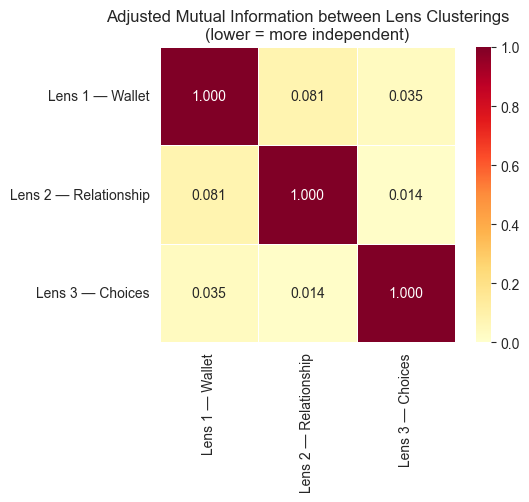

In [15]:

def cluster_independence_matrix(labels_dict):
    """
    Computes pairwise Adjusted Mutual Information between lens cluster labels.
    Low AMI = lenses are capturing independent structure.
    """
    names = list(labels_dict.keys())
    labels = list(labels_dict.values())
    n = len(names)

    ami_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
    for i in range(n):
        for j in range(n):
            ami_matrix.iloc[i, j] = adjusted_mutual_info_score(labels[i], labels[j])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        ami_matrix.astype(float),
        annot=True, fmt='.3f',
        cmap='YlOrRd', vmin=0, vmax=1,
        square=True, linewidths=0.5
    )
    plt.title('Adjusted Mutual Information between Lens Clusterings\n(lower = more independent)')
    plt.tight_layout()
    plt.show()

    return ami_matrix


labels_dict = {
    'Lens 1 — Wallet':       labels_lens1,
    'Lens 2 — Relationship': labels_lens2,
    'Lens 3 — Choices':      labels_lens3,
}

ami_matrix = cluster_independence_matrix(labels_dict)

In [18]:
import numpy as np
from scipy.stats import spearmanr

def mantel_test(dist_mat_a, dist_mat_b, name_a, name_b,
                        n_permutations=99, sample_size=500, random_state=None):
    """
    Mantel test with optional random sampling.
    Correlates the upper triangles of two distance matrices.
    Low correlation = lenses capture independent structure.
    """
    rng = np.random.default_rng(random_state)

    # --- Sample a subset of indices if dataset is large ---
    n = dist_mat_a.shape[0]
    if sample_size < n:
        sample_idx = rng.choice(n, size=sample_size, replace=False)
        dist_mat_a = dist_mat_a[sample_idx][:, sample_idx]
        dist_mat_b = dist_mat_b[sample_idx][:, sample_idx]

    # --- Flatten upper triangles ---
    idx = np.triu_indices_from(dist_mat_a, k=1)
    vec_a = dist_mat_a[idx]
    vec_b = dist_mat_b[idx]

    # --- Observed correlation ---
    observed_r, _ = spearmanr(vec_a, vec_b)

    # --- Permutation test ---
    null_distribution = []
    for _ in range(n_permutations):
        perm = rng.permutation(len(dist_mat_b))
        dist_b_perm = dist_mat_b[perm][:, perm]
        vec_b_perm = dist_b_perm[idx]
        r_perm, _ = spearmanr(vec_a, vec_b_perm)
        null_distribution.append(r_perm)

    # --- p-value ---
    p_value = np.mean(np.abs(null_distribution) >= np.abs(observed_r))

    print(f"Mantel test — {name_a} vs {name_b}:")
    print(f"  r = {observed_r:.3f},  p = {p_value:.3f} ({n_permutations} permutations, sample_size={min(sample_size,n)})")

    return observed_r, p_value

print("Running Mantel tests (this takes a moment)...\n")
mantel_test(dist_mat_lens1, dist_mat_lens2, 'Lens 1', 'Lens 2')
mantel_test(dist_mat_lens1, dist_mat_lens3, 'Lens 1', 'Lens 3')
mantel_test(dist_mat_lens2, dist_mat_lens3, 'Lens 2', 'Lens 3')

Running Mantel tests (this takes a moment)...

Mantel test — Lens 1 vs Lens 2:
  r = 0.283,  p = 0.000 (99 permutations, sample_size=500)
Mantel test — Lens 1 vs Lens 3:
  r = 0.126,  p = 0.000 (99 permutations, sample_size=500)
Mantel test — Lens 2 vs Lens 3:
  r = 0.110,  p = 0.000 (99 permutations, sample_size=500)


(np.float64(0.10957238742917891), np.float64(0.0))